# Modelo 7b — Perfis de uso (clustering K-Means)

Agrupa usuários por padrão de uso — não prevê nada, categoriza. Serve para o gestor
identificar concentração de uso em horário de pico e desenhar incentivos para
redistribuir a carga (ex: desconto para quem carrega de madrugada).

## Features (uma linha por usuário, agregando todo o período mar-ago/2026)

- `n_sessoes_total` — frequência de uso
- `hora_media_inicio` — horário preferencial (média das horas de início, 0-23)
- `kwh_medio_sessao` — consumo médio por sessão (não total, para não se confundir com frequência)
- `duracao_media_min` — duração típica de carregamento
- `pct_fim_semana` — proporção de sessões em fim de semana (captura padrão "final de semana em casa" vs "rotina de dia útil")

Não incluímos `plan_type`: é uma escolha comercial do usuário, não um padrão de
comportamento de uso — misturaria dois tipos de informação diferentes no cluster.

## Escolha de K

K não é fixado a priori — usamos o método do cotovelo (inércia) e o silhouette score
para escolher o número de clusters que melhor separa os perfis nos dados reais.


## Setup

In [8]:
import os
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import psycopg2
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [9]:
DB_CONFIG = {
    "host": os.getenv("POSTGRES_HOST", "localhost"),
    "port": os.getenv("POSTGRES_PORT", "5432"),
    "dbname": os.getenv("POSTGRES_DB", "evchargeops"),
    "user": os.getenv("POSTGRES_USER", "evchargeops"),
    "password": os.getenv("POSTGRES_PASSWORD", ""),
}

# Este notebook é feito para rodar de dentro da pasta models/.
# Os artefatos (joblib, csv) vão para models/output/, separados do
# notebook em si -- e são ignorados no Git (ver .gitignore).
MODELS_DIR = Path("output")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

FEATURES = ["n_sessoes_total", "hora_media_inicio", "kwh_medio_sessao", "duracao_media_min", "pct_fim_semana"]

## Carga e construção das features por usuário

**Nota sobre `hora_media_inicio`**: `fct_sessoes.session_date` é do tipo `DATE` (sem hora) —
a hora do dia da sessão não foi persistida no star schema, só a data. Vamos recalcular a
partir dos dados simulados brutos (`data/raw/simulado/sessions.csv`), que têm a coluna
`session_datetime` completa, e fazer o join com `fct_sessoes` por `session_id`.

In [10]:
def fetch_user_usage_features(conn, sessions_raw_path: Path) -> pd.DataFrame:
    """Uma linha por usuário, agregando todas as sessões do período.
    A hora de início vem do CSV bruto do gerador (data/raw/simulado/sessions.csv),
    já que o star schema só persiste a data (sem hora) em fct_sessoes."""
    raw = pd.read_csv(sessions_raw_path)
    raw["session_datetime"] = pd.to_datetime(raw["session_datetime"])
    raw["hour"] = raw["session_datetime"].dt.hour

    query = """
        SELECT
            s.session_id,
            s.user_id,
            s.kwh_delivered,
            s.duration_min,
            d.is_weekend
        FROM fct_sessoes s
        JOIN dim_dates d ON d.session_date = s.session_date
    """
    sessions_db = pd.read_sql(query, conn)

    merged = sessions_db.merge(raw[["session_id", "hour"]], on="session_id", how="left")

    features = merged.groupby("user_id").agg(
        n_sessoes_total=("session_id", "count"),
        hora_media_inicio=("hour", "mean"),
        kwh_medio_sessao=("kwh_delivered", "mean"),
        duracao_media_min=("duration_min", "mean"),
        pct_fim_semana=("is_weekend", "mean"),
    ).reset_index()

    return features

In [11]:
SESSIONS_RAW_PATH = Path("../data/raw/simulado/sessions.csv")

conn = psycopg2.connect(**DB_CONFIG)
try:
    usage_df = fetch_user_usage_features(conn, SESSIONS_RAW_PATH)
finally:
    conn.close()

print(f"{len(usage_df)} usuários com features de uso calculadas.")
usage_df.describe()

150 usuários com features de uso calculadas.


/tmp/ipykernel_175010/4273143928.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sessions_db = pd.read_sql(query, conn)


,n_sessoes_total,hora_media_inicio,kwh_medio_sessao,duracao_media_min,pct_fim_semana
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,54.873333,15.168906,24.815179,102.172677,0.281523
std,24.411543,0.979023,9.923095,9.068513,0.068654
min,6.000000,11.600000,8.427000,73.500000,0.050000
25%,37.000000,14.531818,15.633604,95.873649,0.239473
50%,54.000000,15.252999,29.003318,102.190364,0.283458
75%,71.000000,15.936111,33.151208,107.858729,0.324519
max,133.000000,17.122807,45.912167,143.700000,0.466667


## Padronização\n\nK-Means é sensível à escala das features (horas 0-23 vs kWh vs minutos) — sem padronizar, a feature com maior variância numérica domina a distância euclidiana.

In [12]:
X = usage_df[FEATURES].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pd.DataFrame(X_scaled, columns=FEATURES).describe()

,n_sessoes_total,hora_media_inicio,kwh_medio_sessao,duracao_media_min,pct_fim_semana
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,-6.513308e-17,-2.753353e-15,2.605323e-16,1.184238e-15,-6.942595e-16
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00
min,-2.008765e+00,-3.657589e+00,-1.657052e+00,-3.172376e+00,-3.383600e+00
25%,-7.346201e-01,-6.529191e-01,-9.283730e-01,-6.969313e-01,-6.145411e-01
50%,-3.589528e-02,8.618238e-02,4.234737e-01,1.956882e-03,2.826955e-02
75%,6.628296e-01,7.862688e-01,8.428777e-01,6.291109e-01,6.283635e-01
max,3.211120e+00,2.002453e+00,2.133172e+00,4.594628e+00,2.705779e+00


## Escolha de K: método do cotovelo + silhouette score

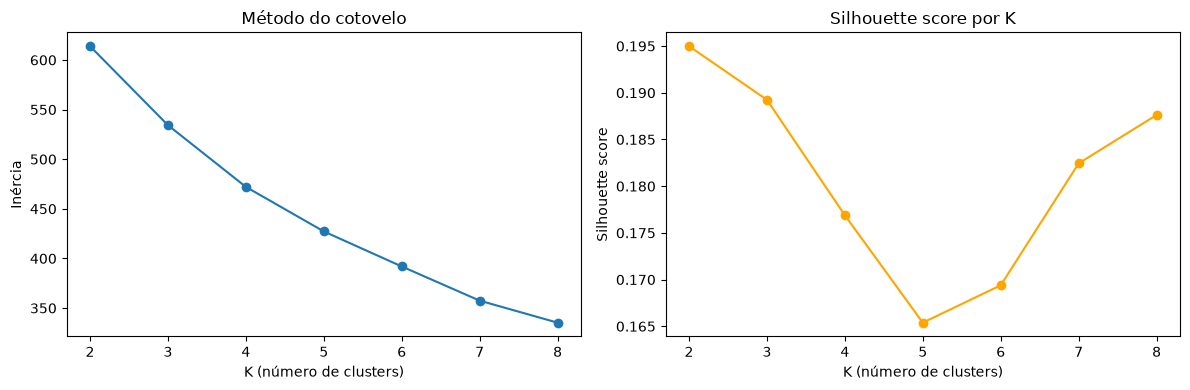

K=2: inércia=613.9, silhouette=0.195
K=3: inércia=534.3, silhouette=0.189
K=4: inércia=472.1, silhouette=0.177
K=5: inércia=427.2, silhouette=0.165
K=6: inércia=391.9, silhouette=0.169
K=7: inércia=357.5, silhouette=0.182
K=8: inércia=335.3, silhouette=0.188


In [13]:
inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_xlabel("K (número de clusters)")
axes[0].set_ylabel("Inércia")
axes[0].set_title("Método do cotovelo")

axes[1].plot(list(k_range), silhouettes, marker="o", color="orange")
axes[1].set_xlabel("K (número de clusters)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score por K")

plt.tight_layout()
plt.show()

for k, inertia, sil in zip(k_range, inertias, silhouettes):
    print(f"K={k}: inércia={inertia:.1f}, silhouette={sil:.3f}")

In [14]:
# A diferença de silhouette score entre os K testados é pequena (0.165 a
# 0.195) -- nenhum K se destaca estatisticamente sobre os outros nesse
# dataset. Isso dá liberdade de escolher com base em valor prático em vez
# de só maximizar a métrica: K=4 oferece segmentação suficiente para o
# gestor agir (ex: incentivos diferenciados por perfil) sem fragmentar os
# 150 usuários em grupos pequenos demais para fazer sentido operacional.
best_k = 4
print(f"K escolhido (fixado, com base no gráfico do cotovelo + silhouette + valor prático): {best_k}")
print(f"Silhouette score para K={best_k}: {silhouettes[list(k_range).index(best_k)]:.3f}")

K escolhido (fixado, com base no gráfico do cotovelo + silhouette + valor prático): 4
Silhouette score para K=4: 0.177


## Treino final com o K escolhido

In [15]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=best_k, random_state=42, n_init=10)),
])

usage_df["cluster"] = pipeline.fit_predict(usage_df[FEATURES])

X_scaled_final = pipeline.named_steps["scaler"].transform(usage_df[FEATURES])
print(f"Silhouette score final (K={best_k}): {silhouette_score(X_scaled_final, usage_df['cluster']):.3f}")

usage_df["cluster"].value_counts().sort_index()

Silhouette score final (K=4): 0.177


cluster
0    32
1    53
2    25
3    40
Name: count, dtype: int64

## Perfil de cada cluster (médias das features, em escala original)

In [16]:
cluster_profile = usage_df.groupby("cluster")[FEATURES + ["n_sessoes_total"]].mean().round(2)
cluster_profile["n_usuarios"] = usage_df["cluster"].value_counts().sort_index()
cluster_profile

,n_sessoes_total,hora_media_inicio,kwh_medio_sessao,duracao_media_min,pct_fim_semana,n_sessoes_total,n_usuarios
cluster,,,,,,,
0,50.38,15.64,31.03,93.81,0.25,50.38,32
1,59.08,15.44,14.32,101.62,0.30,59.08,53
2,33.28,13.92,23.04,107.23,0.23,33.28,25
3,66.40,15.22,34.86,106.43,0.31,66.40,40


## Sobre a escolha de K=4 e os silhouette scores baixos

Vale examinar isso com honestidade em vez de só aceitar o resultado calado. Os
silhouette scores testados (K=2 a K=8) ficaram todos numa faixa estreita —
entre 0.165 e 0.195 — sem nenhum K se destacando estatisticamente dos demais.
Valores acima de 0.5 indicariam clusters bem separados; os nossos indicam
clusters com alguma sobreposição.

Olhando o perfil dos clusters (célula seguinte), a explicação aparece: as
features `n_sessoes_total`, `hora_media_inicio`, `duracao_media_min` e
`pct_fim_semana` variam pouco entre usuários — o desvio padrão de
`hora_media_inicio` é menor que 1 hora entre os 150 usuários simulados. A
feature que mais diferencia os grupos é `kwh_medio_sessao` (consumo médio
por sessão).

Isso é uma característica do **dataset simulado**, não um erro deste
notebook — o gerador de dados (Etapa 3) usa a mesma distribuição de
probabilidade de horário de início para todos os usuários (pico às
18h-23h), sem simular diferentes "personas" de rotina (ex: alguém que só
carrega de manhã antes de sair para o trabalho).

**Por que K=4 mesmo assim**: como a diferença de silhouette entre os K
testados é pequena, escolher pela métrica pura não teria uma justificativa
estatística forte. K=4 foi escolhido por valor prático — dá ao gestor 4
perfis operacionais para agir (ex: incentivos diferenciados) sem
fragmentar demais os 150 usuários em grupos pequenos.

Se o objetivo futuro for segmentar por comportamento temporal de verdade,
o próximo passo seria enriquecer o gerador de dados simulados com personas
de horário distintas por usuário (manhã / tarde / noite / fim de semana),
não ajustar este notebook.


## Persistência dos artefatos

In [17]:
joblib.dump(pipeline, MODELS_DIR / "perfis_uso_kmeans.joblib")
usage_df.to_csv(MODELS_DIR / "perfis_uso_clusters.csv", index=False)

print("Artefatos salvos em:", MODELS_DIR.resolve())
print(" -", "perfis_uso_kmeans.joblib")
print(" -", "perfis_uso_clusters.csv")

Artefatos salvos em: /home/vinivaliati/projects/computer_science_fiap_challenge_2026/models/output
 - perfis_uso_kmeans.joblib
 - perfis_uso_clusters.csv
